In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('C:/Users/LENOVO/tf_gpu/Business_analytics/data/sample_superstore.xls')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [3]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.isna().sum())
print(df.describe(include='all'))

(10194, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194

## Initial observations

- The dataset contains retail order data.
- Key columns include Order Date, Ship Date, Sales, Profit, Quantity, Category, Sub-Category, Region, and Segment.
- The dataset appears suitable for sales, profit, and regional performance analysis.
- Missing values were checked and noted.
- This dataset can help answer business questions related to category performance, customer segments, and profitability.

In [4]:
category_summary = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
      .sort_values("Profit", ascending=False)
)

print(category_summary)

                       Sales       Profit
Category                                 
Technology       839893.2790  146543.3756
Office Supplies  731893.3140  126023.4434
Furniture        754747.7613   19729.9956


In [5]:
subcategory_summary = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
      .sum()
      .sort_values("Profit")
)

print(subcategory_summary)

                    Sales      Profit
Sub-Category                         
Tables        208020.1820 -17753.2061
Bookcases     115361.2043  -3632.0736
Supplies       46725.4980  -1171.3945
Fasteners       8532.2400   2428.6358
Machines      189925.0310   3461.9769
Labels         12695.0420   5572.7780
Art            27659.0140   6653.1962
Envelopes      16528.3620   6988.0247
Furnishings    95598.1260  13891.7430
Appliances    108213.1850  18329.4844
Storage       224644.5540  21285.1115
Chairs        335768.2490  27223.5323
Binders       207354.8810  31426.1003
Paper          79540.5380  34511.5070
Accessories   167380.3180  41936.6357
Phones        331842.6400  45050.8265
Copiers       150745.2900  56093.9365


In [6]:
region_summary = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values("Profit", ascending=False)
)

print(region_summary)

               Sales       Profit
Region                           
West     739813.6085  110798.8170
East     691828.1680   94883.2603
South    391721.9050   46749.4303
Central  503170.6728   39865.3070


In [7]:
discount_summary = (
    df.groupby("Discount")["Profit"]
      .sum()
      .sort_values()
)

print(discount_summary)

Discount
0.70    -40300.5727
0.80    -30565.2692
0.40    -23086.3742
0.50    -20506.4281
0.30    -10513.4456
0.60     -6164.3472
0.45     -2493.1111
0.32     -2391.1377
0.15      1418.9915
0.10      9099.9700
0.20     91079.9517
0.00    326718.5872
Name: Profit, dtype: float64


In [8]:
category_margin = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
      .assign(profit_margin=lambda x: x["Profit"] / x["Sales"])
      .sort_values("profit_margin", ascending=False)
)

print(category_margin)

                       Sales       Profit  profit_margin
Category                                                
Technology       839893.2790  146543.3756       0.174479
Office Supplies  731893.3140  126023.4434       0.172188
Furniture        754747.7613   19729.9956       0.026141


## Insights

The analysis shows that Tables is the most loss-making sub-category. In addition, profit appears to decline as discount levels increase. This suggests that discounting may be one of the key drivers of poor profitability, particularly in already weak product areas. A business recommendation would be to review discount strategy and margin structure for Tables and similar low-performing products.

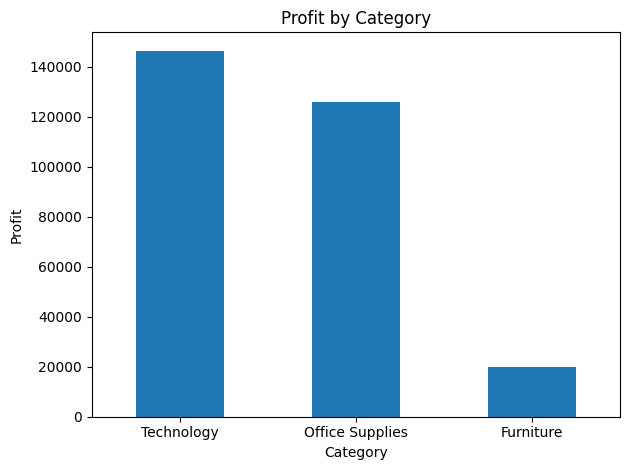

In [9]:
category_summary["Profit"].plot(kind="bar")
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

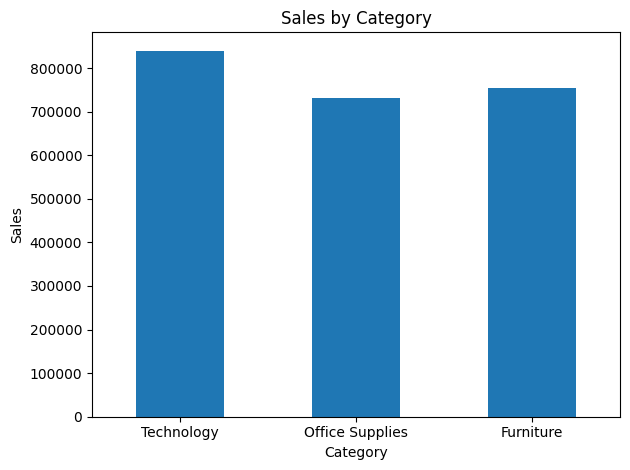

In [10]:
category_summary["Sales"].plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

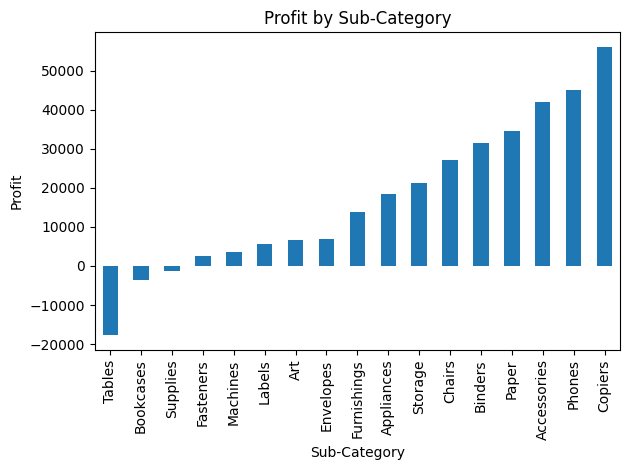

In [11]:
subcategory_summary["Profit"].plot(kind="bar")
plt.title("Profit by Sub-Category")
plt.ylabel("Profit")
plt.xlabel("Sub-Category")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

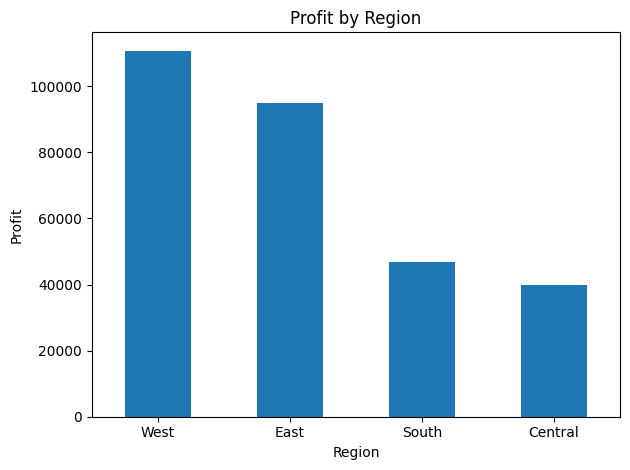

In [12]:
region_summary["Profit"].plot(kind="bar")
plt.title("Profit by Region")
plt.ylabel("Profit")
plt.xlabel("Region")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

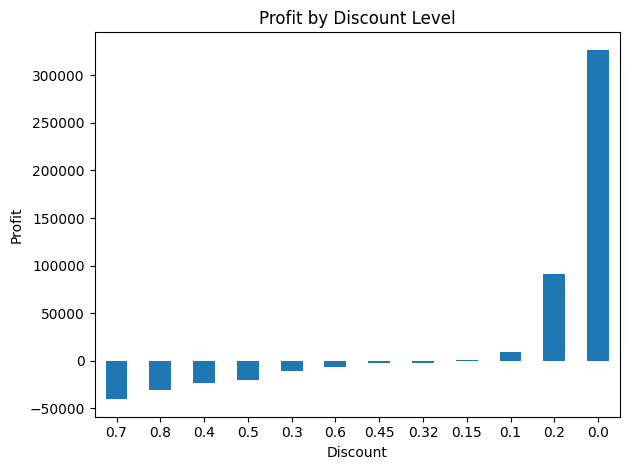

In [13]:
discount_summary.plot(kind="bar")
plt.title("Profit by Discount Level")
plt.ylabel("Profit")
plt.xlabel("Discount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Insights

- Category-level charts confirm that Technology leads in both sales and profit.
- Furniture continues to underperform in profit relative to its sales.
- Sub-category analysis shows that Tables is one of the most problematic areas.
- Discount-level analysis suggests that higher discounts reduce total profit.
- Regional analysis shows that profitability is not evenly distributed across markets.
- Product-level analysis reveals that some products generate sales but still destroy margin.